# Elliptic Bitcoin Baselines

This notebook fits feature-only baseline classifiers on the known Elliptic Bitcoin labels. Unknown labels are excluded from supervised training and evaluation. A stratified fraction of known labels is held out so these numbers can be compared with the MCEM held-out known-label evaluation.

In [2]:
import importlib.util
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB and importlib.util.find_spec("torch_geometric") is None:
    %pip install -q torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.0 MB/s eta 0:00:00a 0:00:01


In [3]:
from pathlib import Path
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from torch_geometric.datasets import EllipticBitcoinDataset

## Configuration

In [12]:
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "script" else NOTEBOOK_DIR

if IN_COLAB:
    DATA_ROOT = Path("/content/data/EllipticBitcoinDataset")
else:
    DATA_ROOT = PROJECT_ROOT / "data" / "EllipticBitcoinDataset"

NUM_FEATURES = 94          # Use 94 to match the MCEM notebook default; use 165 for all PyG features.
VALIDATION_FRACTION = 0.3  # Stratified holdout from known labels only.
SEED = 305

DATA_ROOT

PosixPath('/content/data/EllipticBitcoinDataset')

## Helper Functions

In [5]:
def load_elliptic_arrays(data_root=DATA_ROOT, num_features=NUM_FEATURES):
    """Load node features and raw PyG labels.

    Label mapping in this project: 0=licit, 1=illicit, 2=unknown.
    """
    dataset = EllipticBitcoinDataset(root=str(data_root))
    data = dataset[0]
    X = data.x.cpu().numpy()
    y_raw = data.y.cpu().numpy().astype(int)
    if num_features is not None:
        X = X[:, :num_features]
    return X, y_raw, data


def make_known_label_split(y_raw, validation_fraction=VALIDATION_FRACTION, seed=SEED):
    known_idx = np.flatnonzero(y_raw != 2)
    y_known = (y_raw[known_idx] == 1).astype(int)

    train_idx, validation_idx = train_test_split(
        known_idx,
        test_size=validation_fraction,
        random_state=seed,
        stratify=y_known,
    )

    return {
        "train_idx": train_idx,
        "validation_idx": validation_idx,
        "y_train": (y_raw[train_idx] == 1).astype(int),
        "y_validation": (y_raw[validation_idx] == 1).astype(int),
    }


def make_baseline_models(seed=SEED):
    return {
        "Logistic Regression": make_pipeline(
            StandardScaler(),
            LogisticRegression(
                class_weight="balanced",
                max_iter=2000,
                random_state=seed,
            ),
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced_subsample",
            min_samples_leaf=2,
            n_jobs=-1,
            random_state=seed,
        ),
    }


def evaluate_classifier(model, X_validation, y_validation):
    y_pred = model.predict(X_validation)
    y_score = model.predict_proba(X_validation)[:, 1]

    metrics = {
        "accuracy": float(accuracy_score(y_validation, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_validation, y_pred)),
        "precision_illicit": float(precision_score(y_validation, y_pred, zero_division=0)),
        "recall_illicit": float(recall_score(y_validation, y_pred, zero_division=0)),
        "f1_illicit": float(f1_score(y_validation, y_pred, zero_division=0)),
        "confusion_matrix_licit_illicit": confusion_matrix(y_validation, y_pred, labels=[0, 1]).tolist(),
    }

    if np.unique(y_validation).size == 2:
        metrics["roc_auc"] = float(roc_auc_score(y_validation, y_score))
        metrics["average_precision"] = float(average_precision_score(y_validation, y_score))
    else:
        metrics["roc_auc"] = np.nan
        metrics["average_precision"] = np.nan

    return metrics

## Load Data

In [6]:
X, y_raw, data = load_elliptic_arrays()
split = make_known_label_split(y_raw)

X_train = X[split["train_idx"]]
X_validation = X[split["validation_idx"]]
y_train = split["y_train"]
y_validation = split["y_validation"]

print(data)
print(f"Known labels: {(y_raw != 2).sum():,}")
print(f"Training labels: {y_train.size:,} licit={(y_train == 0).sum():,} illicit={(y_train == 1).sum():,}")
print(f"Held-out labels: {y_validation.size:,} licit={(y_validation == 0).sum():,} illicit={(y_validation == 1).sum():,}")

Processing...
Done!


Data(x=[203769, 165], edge_index=[2, 234355], y=[203769], train_mask=[203769], test_mask=[203769])
Known labels: 46,564
Training labels: 37,251 licit=33,615 illicit=3,636
Held-out labels: 9,313 licit=8,404 illicit=909


## Fit Baselines

In [13]:
rows = []
models = {}

for model_name, model in make_baseline_models().items():
    start = time.perf_counter()
    model.fit(X_train, y_train)
    fit_seconds = time.perf_counter() - start
    metrics = evaluate_classifier(model, X_validation, y_validation)

    rows.append({
        "model": model_name,
        "num_features": X.shape[1],
        "num_train": int(y_train.size),
        "num_validation": int(y_validation.size),
        "train_licit": int((y_train == 0).sum()),
        "train_illicit": int((y_train == 1).sum()),
        "validation_licit": int((y_validation == 0).sum()),
        "validation_illicit": int((y_validation == 1).sum()),
        "fit_seconds": fit_seconds,
        **metrics,
    })
    models[model_name] = model

baseline_results = pd.DataFrame(rows).sort_values("f1_illicit", ascending=False)
baseline_results

,model,num_features,num_train,num_validation,train_licit,train_illicit,validation_licit,validation_illicit,fit_seconds,accuracy,balanced_accuracy,precision_illicit,recall_illicit,f1_illicit,confusion_matrix_licit_illicit,roc_auc,average_precision
1,Random Forest,94,37251,9313,33615,3636,8404,909,43.488300,0.987544,0.939628,0.991326,0.880088,0.932401,"[[8397, 7], [109, 800]]",0.995127,0.978683
0,Logistic Regression,94,37251,9313,33615,3636,8404,909,4.210447,0.826157,0.873753,0.352452,0.932893,0.511614,"[[6846, 1558], [61, 848]]",0.958308,0.697076


In [8]:
display_cols = [
    "model",
    "accuracy",
    "balanced_accuracy",
    "precision_illicit",
    "recall_illicit",
    "f1_illicit",
    "roc_auc",
    "average_precision",
    "fit_seconds",
]
baseline_results[display_cols]

,model,accuracy,balanced_accuracy,precision_illicit,recall_illicit,f1_illicit,roc_auc,average_precision,fit_seconds
1,Random Forest,0.987544,0.939628,0.991326,0.880088,0.932401,0.995127,0.978683,38.765054
0,Logistic Regression,0.826157,0.873753,0.352452,0.932893,0.511614,0.958308,0.697076,4.189308


In [9]:
baseline_results[["model", "confusion_matrix_licit_illicit"]]

,model,confusion_matrix_licit_illicit
1,Random Forest,"[[8397, 7], [109, 800]]"
0,Logistic Regression,"[[6846, 1558], [61, 848]]"


## Metric Plot

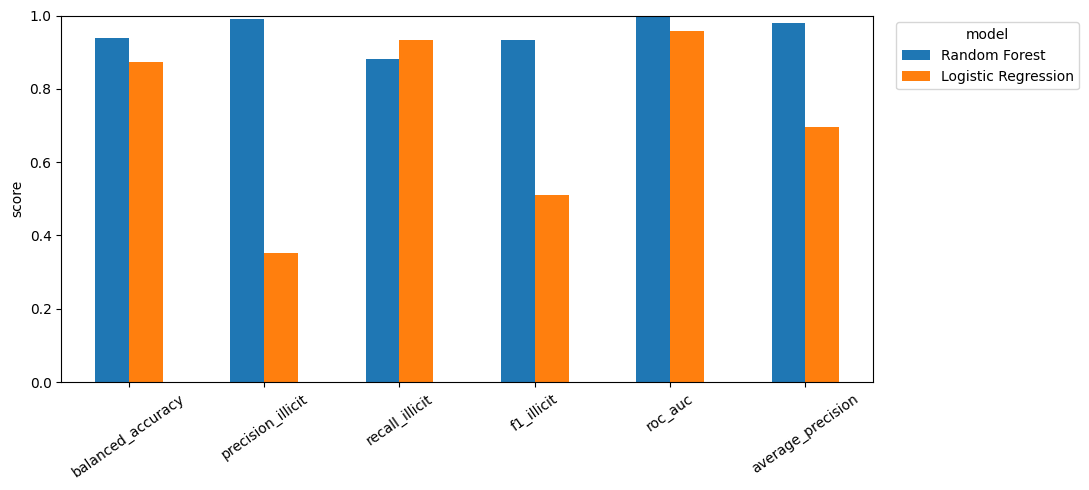

In [10]:
metric_cols = ["balanced_accuracy", "precision_illicit", "recall_illicit", "f1_illicit", "roc_auc", "average_precision"]
plot_df = baseline_results.set_index("model")[metric_cols]

ax = plot_df.T.plot(kind="bar", figsize=(11, 5), rot=35)
ax.set_ylim(0, 1)
ax.set_ylabel("score")
ax.set_xlabel("")
ax.legend(title="model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

## Save Results

In [11]:
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=True)
    OUTPUT_DIR = Path("/content/drive/MyDrive/stat305c_ising_runs")
else:
    OUTPUT_DIR = PROJECT_ROOT / "script"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH = OUTPUT_DIR / "baseline_results.csv"
baseline_results.to_csv(OUTPUT_PATH, index=False)

print("Saved baseline results to", OUTPUT_PATH)
OUTPUT_PATH

Mounted at /content/drive
Saved baseline results to /content/drive/MyDrive/stat305c_ising_runs/baseline_results.csv


PosixPath('/content/drive/MyDrive/stat305c_ising_runs/baseline_results.csv')